# XAI Lab: Visual explanations


Complete the coding exercises below.

The dataset we will be using is **DermaMNIST**, a subset of the MedMNIST benchmark derived from the HAM10000 collection of dermatoscopic images. It contains skin lesion images across 7 diagnostic categories (e.g., melanoma, nevus, basal cell carcinoma). Each image is a 3-channel RGB photo of a skin lesion, resized to 28×28 pixels in the original benchmark (we upscale to 128×128 here). We will train a CNN classifier on this dataset and apply various saliency-based attribution methods to explain its predictions.

In [34]:
!pip install medmnist
!pip install captum --no-deps
!pip install opencv

ERROR: Could not find a version that satisfies the requirement opencv (from versions: none)
ERROR: No matching distribution found for opencv


In [35]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F

import medmnist
from medmnist import INFO
from medmnist.dataset import DermaMNIST

from captum.attr import Saliency, NoiseTunnel, LayerGradCam, LayerAttribution, LRP
import cv2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [36]:
data_flag = 'dermamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# Transform (resize - optional)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Load datasets
train_dataset = DataClass(split='train', transform=transform, download=True, size=128)
val_dataset   = DataClass(split='val',   transform=transform, download=True, size=128)
test_dataset  = DataClass(split='test',  transform=transform, download=True, size=128)

# Build loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)


In [37]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.conv1 = block(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = block(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = block(64, 128)

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x_gap = self.gap(x).view(x.size(0), -1)
        out = self.fc(x_gap)
        return out

model = SimpleCNN(num_classes=7).to(device)

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for imgs, lbls in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        imgs, lbls = imgs.to(device), lbls.squeeze().long().to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")

Epoch 1: 100%|██████████| 110/110 [00:20<00:00,  5.24it/s]


Epoch 1, Train Loss: 0.9876


Epoch 2: 100%|██████████| 110/110 [00:18<00:00,  6.01it/s]


Epoch 2, Train Loss: 0.8404


Epoch 3: 100%|██████████| 110/110 [00:18<00:00,  5.84it/s]


...

Epoch 8, Train Loss: 0.7253


Epoch 9: 100%|██████████| 110/110 [00:19<00:00,  5.75it/s]


Epoch 9, Train Loss: 0.7089


Epoch 10: 100%|██████████| 110/110 [00:19<00:00,  5.78it/s]

Epoch 10, Train Loss: 0.7105


In [39]:
model.eval()

seed = 43
torch.manual_seed(seed)

# Pick a random image from validation loader
val_iter = iter(val_loader)
img_batch, label_batch = next(val_iter)
rand_idx = torch.randint(0, img_batch.size(0), (1,)).item()
img, label = img_batch[rand_idx:rand_idx+1].to(device), label_batch[rand_idx].item()

print(f"Selected image index: {rand_idx}, label: {label}")

Selected image index: 63, label: 2


We have defined a model, trained it on the data for a few epochs and picked one image from the validation set.
- Compute the following attribution maps for the selected image:
  - **Task (1.5 point)** Vanilla Gradients
  - **Task (2 points)** SmoothGrad
  - **Task (2 points)** GradCAM
  - **Task (2 points)** LRP

  (Optional: Try to implement some of the methods above without using Captum).

- **Task (0.5 point)** Visualize the original image and all attribution maps side-by-side in a single figure
- **Task (1 point)** Identify two missclassified samples and compute all 4 attribution maps for each.
- **Task (1 point)** Quantify how much each attrbution method focuses on the object vs background:
  - For a selected image, define a central mask (e.g., central 50% of the image) as the “object region”.
  - For each attribution map compute the fraction of saliency inside the object region

### Coding tasks:

### Contributing Students

vandeje1: Jeremy van der Schans

zimmeni4: Nina Zimmermann

Compute the following attribution maps for the selected image:
- **Task (1.5 point)** Vanilla Gradients

In [40]:
saliency = Saliency(model)
vanilla_grad = saliency.attribute(img, target=label)
vanilla_grad = vanilla_grad.squeeze().cpu().detach().numpy()
vanilla_grad = np.abs(vanilla_grad).mean(axis=0)

- **Task (2 points)** SmoothGrad

In [41]:
nt = NoiseTunnel(saliency)
smooth_grad = nt.attribute(img, nt_samples=50, nt_type='smoothgrad', target=label)
smooth_grad = smooth_grad.squeeze().cpu().detach().numpy()
smooth_grad = np.abs(smooth_grad).mean(axis=0)

- **Task (2 points)** GradCAM

In [42]:
layer_gradcam = LayerGradCam(model, model.conv3)
gradcam = layer_gradcam.attribute(img, target=label)
gradcam = gradcam.squeeze().cpu().detach().numpy()
gradcam = cv2.resize(gradcam, (128, 128), interpolation=cv2.INTER_LINEAR)

- **Task (2 points)** LRP (below with Captum)

In [43]:
lrp = LRP(model)
lrp_attr = lrp.attribute(img, target=label)
lrp_attr = lrp_attr.squeeze().cpu().detach().numpy()
lrp_attr = np.abs(lrp_attr).mean(axis=0)

**Task (0.5 point)** Visualize the original image and all attribution maps side-by-side in a single figure

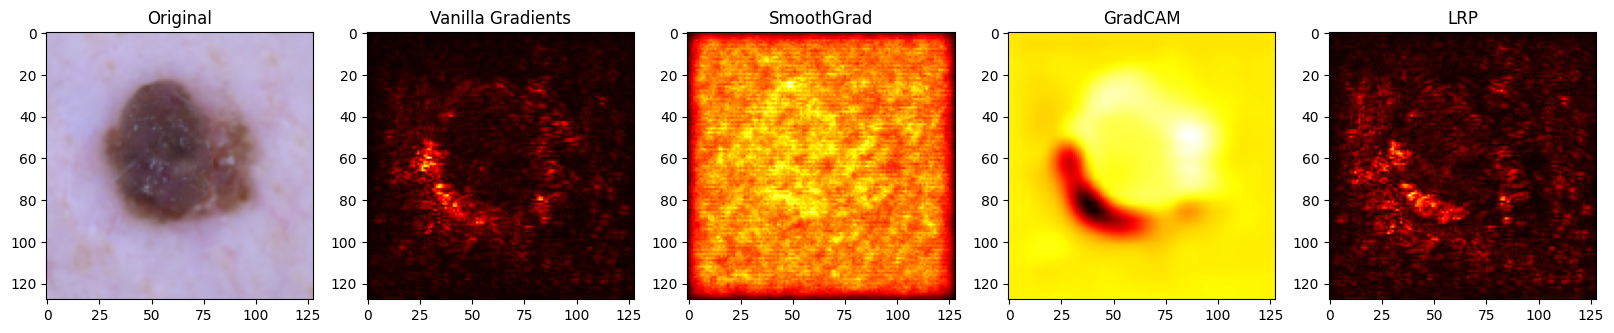

In [47]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

img_np = img.squeeze().cpu().detach().numpy()
img_np = (img_np + 1) / 2
img_np = np.transpose(img_np, (1, 2, 0))

axes[0].imshow(img_np)
axes[0].set_title("Original")

axes[1].imshow(vanilla_grad, cmap='hot')
axes[1].set_title("Vanilla Gradients")

axes[2].imshow(smooth_grad, cmap='hot')
axes[2].set_title("SmoothGrad")

axes[3].imshow(gradcam, cmap='hot')
axes[3].set_title("GradCAM")

axes[4].imshow(lrp_attr, cmap='hot')
axes[4].set_title("LRP")

plt.show()

**Task (1 point)** Identify two missclassified samples and compute all 4 attribution maps for each.

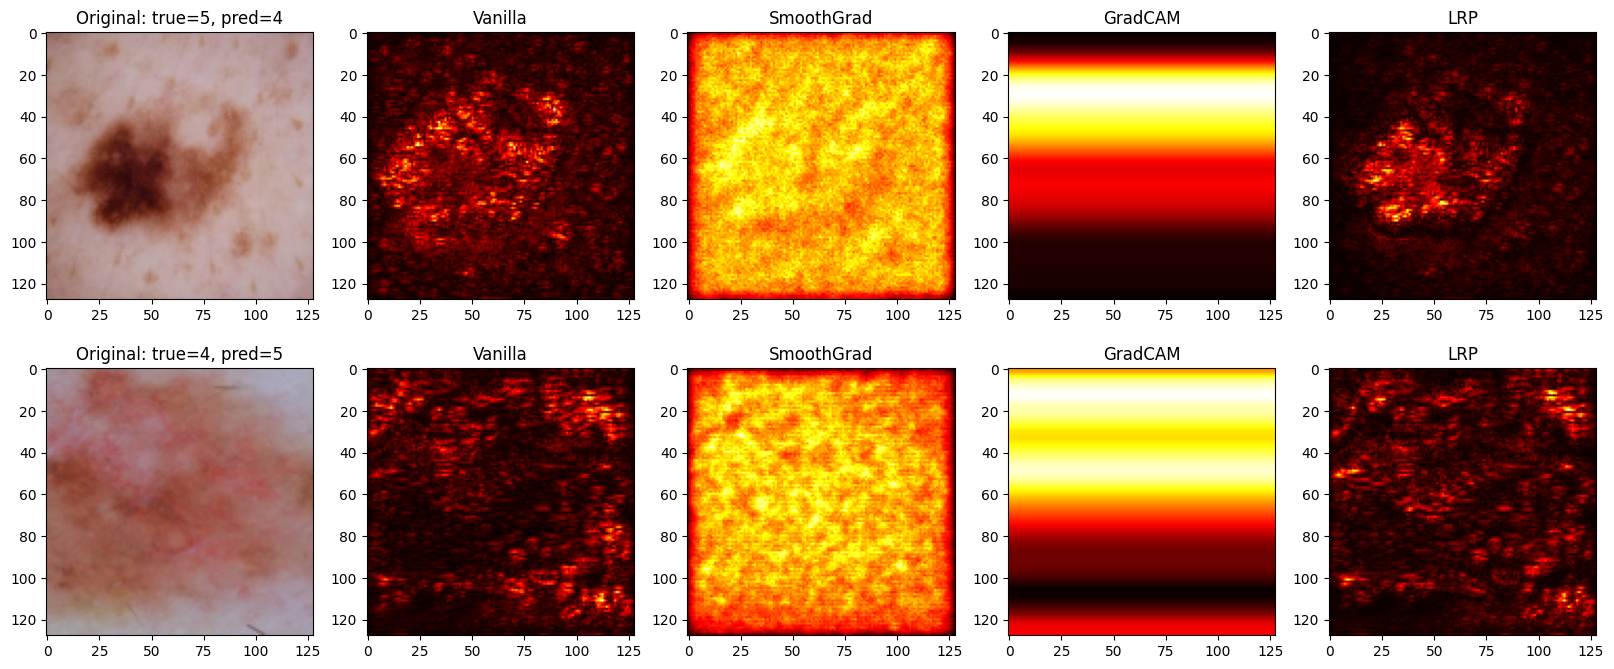

In [45]:
misclassified = []

with torch.no_grad():
    for batch_img, batch_lbl in val_loader:
        batch_img, batch_lbl = batch_img.to(device), batch_lbl.squeeze().long().to(device)
        preds = model(batch_img).argmax(dim=1)

        wrong_mask = (preds != batch_lbl).nonzero(as_tuple=True)[0]
        for idx in wrong_mask[:10]:
            misclassified.append({
                'img': batch_img[idx:idx + 1],
                'true_label': batch_lbl[idx].item(),
                'pred_label': preds[idx].item()
            })

        if len(misclassified) >= 2:
            break

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for row, sample in enumerate(misclassified[:2]):
    sample_img = sample['img']
    pred_lbl = sample['pred_label']

    vanilla = Saliency(model).attribute(sample_img, target=pred_lbl)
    vanilla = np.abs(vanilla.squeeze().cpu().detach().numpy()).mean(axis=0)

    smooth = NoiseTunnel(Saliency(model)).attribute(sample_img, nt_samples=50, nt_type='smoothgrad', target=pred_lbl)
    smooth = np.abs(smooth.squeeze().cpu().detach().numpy()).mean(axis=0)

    grad_cam = LayerGradCam(model, model.conv3).attribute(sample_img, target=pred_lbl)
    grad_cam = np.abs(grad_cam.squeeze().cpu().detach().numpy()).mean(axis=0)
    grad_cam = cv2.resize(grad_cam, (128, 128), interpolation=cv2.INTER_LINEAR)

    lrp_map = LRP(model).attribute(sample_img, target=pred_lbl)
    lrp_map = np.abs(lrp_map.squeeze().cpu().detach().numpy()).mean(axis=0)

    img_vis = sample_img.squeeze().cpu().detach().numpy()
    img_vis = (img_vis + 1) / 2
    img_vis = np.transpose(img_vis, (1, 2, 0))

    axes[row, 0].imshow(img_vis)
    axes[row, 0].set_title(f"Original: true={sample['true_label']}, pred={pred_lbl}")

    axes[row, 1].imshow(vanilla, cmap='hot')
    axes[row, 1].set_title("Vanilla")

    axes[row, 2].imshow(smooth, cmap='hot')
    axes[row, 2].set_title("SmoothGrad")

    axes[row, 3].imshow(grad_cam, cmap='hot')
    axes[row, 3].set_title("GradCAM")

    axes[row, 4].imshow(lrp_map, cmap='hot')
    axes[row, 4].set_title("LRP")

plt.show()

**Task (1 point)** Quantify how much each attrbution method focuses on the object vs background

In [46]:
H, W = 128, 128
mask_size = int(np.sqrt(0.5) * min(H, W))
y_start, x_start = (H - mask_size) // 2, (W - mask_size) // 2
object_mask = np.zeros((H, W))
object_mask[y_start:y_start + mask_size, x_start:x_start + mask_size] = 1.0

def ratio(attr, mask):
    return np.sum(attr * mask) / np.sum(attr) if np.sum(attr) > 0 else 0

print(f"Vanilla: {100 * ratio(vanilla_grad, object_mask):.1f}%")
print(f"SmoothGrad: {100 * ratio(smooth_grad, object_mask):.1f}%")
print(f"GradCAM: {100 * ratio(gradcam, object_mask):.1f}%")
print(f"LRP: {100 * ratio(lrp_attr, object_mask):.1f}%")

Vanilla: 70.3%
SmoothGrad: 55.1%
GradCAM: 76.1%
LRP: 61.3%
